<a href="https://colab.research.google.com/github/surajkeshri836/gitlab/blob/main/Linear_Regression(Sep_A)shared.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')

In [2]:
# Choose the used-cars CSV file from your computer
from google.colab import files

uploaded = files.upload()
csv_file = next(iter(uploaded))
df = pd.read_csv(csv_file)

print('Shape:', df.shape)
df.head()

Saving car_price_dataset.csv to car_price_dataset (1).csv
Shape: (2000, 11)


,Car_ID,Brand,Model_Year,Engine_Size,Fuel_Type,Transmission,Mileage,Doors,Owner_Count,Horsepower,Price
0,1,Ford,2023,1.2,Hybrid,Manual,180635,4,3,82,34309.25
1,2,Hyundai,2018,3.2,Electric,Manual,35628,2,4,259,55153.60
2,3,BMW,2008,2.2,Diesel,Manual,74672,3,2,333,41894.40
3,4,Hyundai,2017,2.2,Petrol,Automatic,51246,4,4,381,54046.70
4,5,Hyundai,2012,2.4,Electric,Manual,147233,3,4,290,38010.35


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Car_ID        2000 non-null   int64  
 1   Brand         2000 non-null   object 
 2   Model_Year    2000 non-null   int64  
 3   Engine_Size   2000 non-null   float64
 4   Fuel_Type     2000 non-null   object 
 5   Transmission  2000 non-null   object 
 6   Mileage       2000 non-null   int64  
 7   Doors         2000 non-null   int64  
 8   Owner_Count   2000 non-null   int64  
 9   Horsepower    2000 non-null   int64  
 10  Price         2000 non-null   float64
dtypes: float64(2), int64(6), object(3)
memory usage: 172.0+ KB


In [4]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.drop_duplicates(inplace=True)

In [12]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.isnull().sum()

,0
Car_ID,0
Brand,0
Model_Year,0
Engine_Size,0
Fuel_Type,0
Transmission,0
Mileage,0
Doors,0
Owner_Count,0
Horsepower,0


In [8]:
numeric_cols = df.select_dtypes(include = "number")
print(numeric_cols)

      Car_ID  Model_Year  Engine_Size  Mileage  Doors  Owner_Count  \
0          1        2023          1.2   180635      4            3   
1          2        2018          3.2    35628      2            4   
2          3        2008          2.2    74672      3            2   
3          4        2017          2.2    51246      4            4   
4          5        2012          2.4   147233      3            4   
...      ...         ...          ...      ...    ...          ...   
1995    1996        2023          4.5   155033      2            3   
1996    1997        2023          1.4    25044      2            4   
1997    1998        2022          4.1   104372      4            3   
1998    1999        2020          4.4   158047      4            1   
1999    2000        2012          1.7    19706      3            1   

      Horsepower     Price  
0             82  34309.25  
1            259  55153.60  
2            333  41894.40  
3            381  54046.70  
4            2

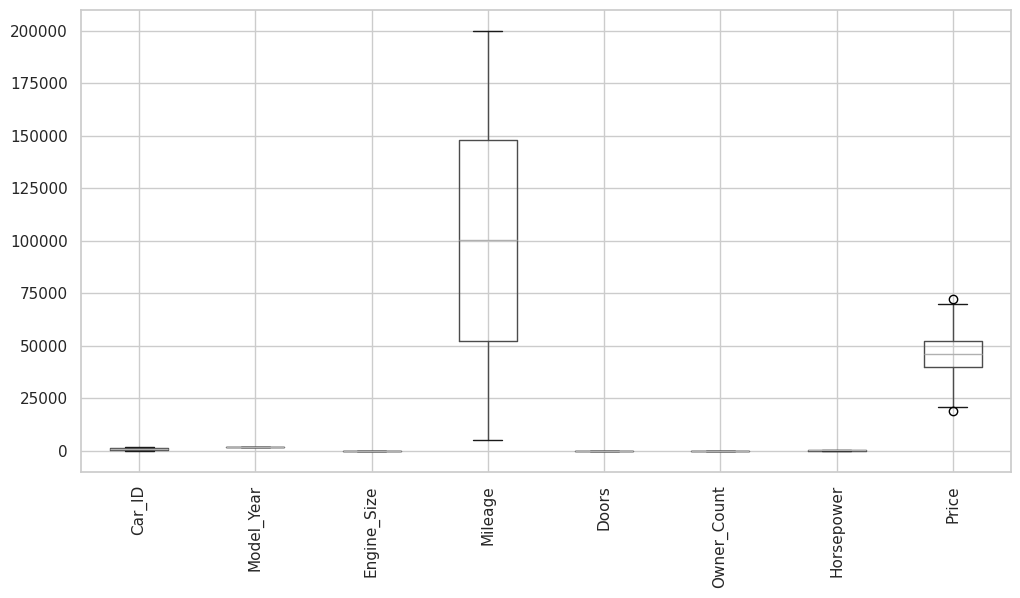

In [9]:
numeric_cols.boxplot(figsize =(12,6))
plt.xticks(rotation = 90)
plt.show()

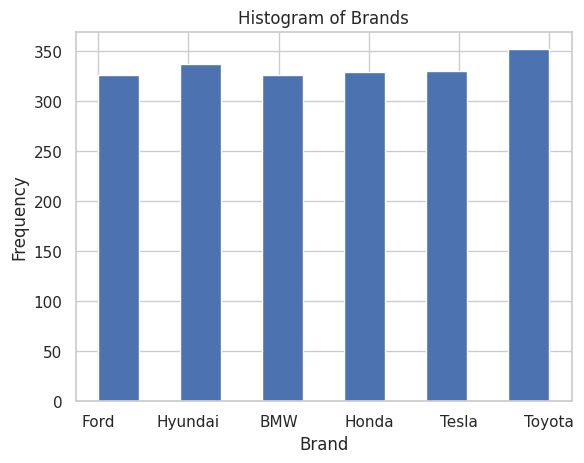

In [21]:
# Univariate
import matplotlib.pyplot as plt
df["Brand"].hist(bins = 11)
plt.title("Histogram of Brands")
plt.xlabel("Brand")
plt.ylabel("Frequency")
plt.show()

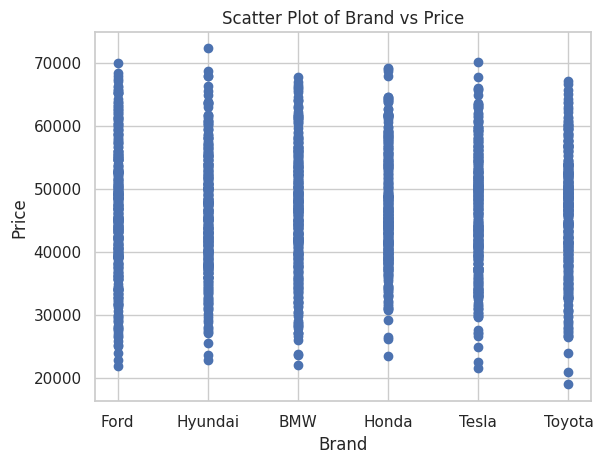

In [37]:
#bivariate
plt.scatter(df["Brand"], df["Price"])
plt.title("Scatter Plot of Brand vs Price")
plt.xlabel("Brand")
plt.ylabel("Price")
plt.show()


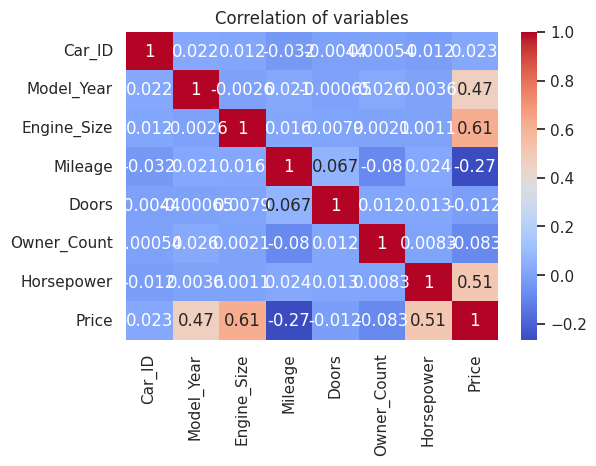

In [34]:
# multivariate
corr = df.corr(numeric_only = True)
plt.figure(figsize= (6,4))
sns.heatmap(corr, annot = True, cmap = "coolwarm")
plt.title("Correlation of variables")
plt.show()

In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Car_ID        2000 non-null   int64  
 1   Brand         2000 non-null   object 
 2   Model_Year    2000 non-null   int64  
 3   Engine_Size   2000 non-null   float64
 4   Fuel_Type     2000 non-null   object 
 5   Transmission  2000 non-null   object 
 6   Mileage       2000 non-null   int64  
 7   Doors         2000 non-null   int64  
 8   Owner_Count   2000 non-null   int64  
 9   Horsepower    2000 non-null   int64  
 10  Price         2000 non-null   float64
dtypes: float64(2), int64(6), object(3)
memory usage: 172.0+ KB


In [39]:
#let's separate dependent and independent variables
X = df.drop(columns = ["Price"]) #independent
y = df["Price"] #dependent

In [41]:
X.head()

,Car_ID,Brand,Model_Year,Engine_Size,Fuel_Type,Transmission,Mileage,Doors,Owner_Count,Horsepower
0,1,Ford,2023,1.2,Hybrid,Manual,180635,4,3,82
1,2,Hyundai,2018,3.2,Electric,Manual,35628,2,4,259
2,3,BMW,2008,2.2,Diesel,Manual,74672,3,2,333
3,4,Hyundai,2017,2.2,Petrol,Automatic,51246,4,4,381
4,5,Hyundai,2012,2.4,Electric,Manual,147233,3,4,290


In [43]:
y.head()

,Price
0,34309.25
1,55153.60
2,41894.40
3,54046.70
4,38010.35


In [44]:
# let's convert object data type into numerical data type
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()


In [60]:
#let's convert object data type to numerical data type
X["Brand"] = le.fit_transform(X["Brand"]).astype(int)
X["Fuel_Type"] = le.fit_transform(X["Fuel_Type"]).astype(int)
X["Transmission"] = le.fit_transform(X["Transmission"]).astype(int)

In [61]:
d_types = X.dtypes
print(d_types)

Car_ID            int64
Brand             int64
Model_Year        int64
Engine_Size     float64
Fuel_Type         int64
Transmission      int64
Mileage           int64
Doors             int64
Owner_Count       int64
Horsepower        int64
dtype: object


In [64]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)
X_train.shape, X_test.shape, y_train.shape, y_test.shape


((1600, 10), (400, 10), (1600,), (400,))

In [67]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [73]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [69]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [77]:
y_pred = model.predict(X_test)
y_pred

array([42319.8104117 , 44290.21115899, 54267.81153872, 52760.97872095,
       54035.08615797, 48112.22888259, 47243.05920761, 61511.37226107,
       38564.65659292, 52249.35362801, 43669.1914252 , 43971.44950597,
       51252.10491136, 41857.66037856, 41155.70537984, 45637.01662895,
       50746.71007911, 63521.44128774, 41148.02612681, 51094.51584926,
       38439.7289119 , 42251.74635903, 56739.26397974, 41360.64056115,
       45098.12328456, 48916.34262582, 51620.47645268, 54459.19482349,
       46449.36098013, 36288.24433129, 33114.78583139, 37607.31927096,
       48314.1772757 , 40949.12430976, 33756.37960128, 58088.50851702,
       44954.3291412 , 50269.03633732, 51502.99576417, 46510.47324113,
       53731.07890453, 60561.49232781, 25312.68344522, 46308.8733524 ,
       42635.51071025, 43105.01260227, 43435.46030119, 57529.74278892,
       44763.56004685, 57868.22701952, 54427.51917494, 44847.59626258,
       45726.70158143, 36675.46925208, 50051.42599957, 45682.91101759,
      

In [80]:
comparison = pd.DataFrame({"Actual": y_test, "Predicted": y_pred})
comparison.head(10)

,Actual,Predicted
1860,43212.35,42319.810412
353,46083.40,44290.211159
1333,52442.80,54267.811539
905,52911.10,52760.978721
1289,56364.50,54035.086158
1273,48364.90,48112.228883
938,49984.80,47243.059208
1731,61124.75,61511.372261
65,35864.65,38564.656593
1323,53218.25,52249.353628


In [82]:
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("Mean Squared Error:", mse)
print("Mean Absolute Error:", mae)
print("R-squared:", r2)

Mean Squared Error: 2777613.6015444673
Mean Absolute Error: 1447.2613550185938
R-squared: 0.966339772081175


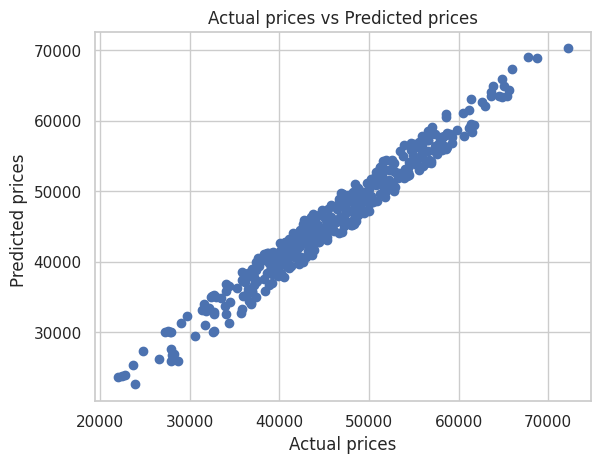

In [86]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual prices")
plt.ylabel("Predicted prices ")
plt.title("Actual prices vs Predicted prices")
plt.show()

In [89]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Car_ID        2000 non-null   int64  
 1   Brand         2000 non-null   int64  
 2   Model_Year    2000 non-null   int64  
 3   Engine_Size   2000 non-null   float64
 4   Fuel_Type     2000 non-null   int64  
 5   Transmission  2000 non-null   int64  
 6   Mileage       2000 non-null   int64  
 7   Doors         2000 non-null   int64  
 8   Owner_Count   2000 non-null   int64  
 9   Horsepower    2000 non-null   int64  
dtypes: float64(1), int64(9)
memory usage: 156.4 KB


In [91]:
print("coeffiecents:",model.coef_)
print("intercept:",model.intercept_)

coeffiecents: [ 6.23283273e+00 -3.59609597e+01  1.43538265e+04  1.98623548e+04
  1.51538845e+02  7.77757716e+01 -9.80498289e+03 -9.93693951e+01
 -3.03198908e+03  1.65325830e+04]
intercept: 27250.060766409246


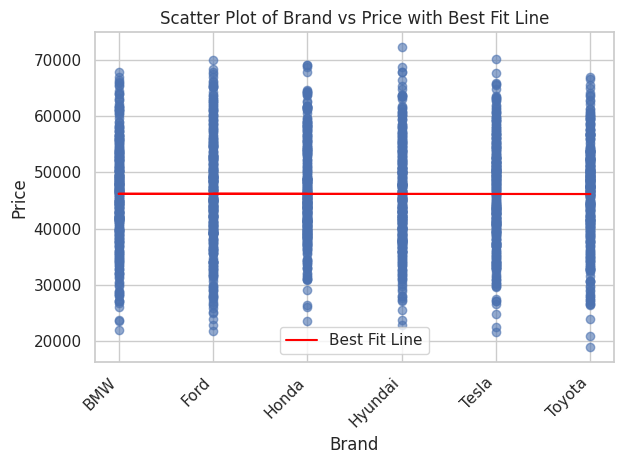

In [98]:
# best fit line for Brand vs Price

# Get unique encoded brand values
unique_encoded_brands = np.sort(X['Brand'].unique())

# To get the original brand names, we need to use a LabelEncoder fitted on the original 'Brand' column.
# This is necessary because the global 'le' object was re-fitted for other columns.
temp_le_brand = LabelEncoder()
temp_le_brand.fit(df['Brand']) # Fit on the original categorical 'Brand' column
original_brand_names = temp_le_brand.inverse_transform(unique_encoded_brands)

# Plot scatter of encoded Brand vs Price
plt.scatter(X['Brand'], y, alpha=0.6)

# Fit a linear regression line using encoded Brand and Price
m, c = np.polyfit(X['Brand'], y, 1)

# Plot the best fit line
plt.plot(X['Brand'], m * X['Brand'] + c, color='red', label='Best Fit Line')

# Set x-axis labels to original brand names for readability
plt.xticks(unique_encoded_brands, original_brand_names, rotation=45, ha='right')

plt.xlabel('Brand')
plt.ylabel('Price')
plt.title('Scatter Plot of Brand vs Price with Best Fit Line')
plt.legend()
plt.tight_layout()
plt.show()